# Brazilian E-Commerce Analysis
**Dataset:** Olist Brazilian E-Commerce (Kaggle)  
**Author:** Nataliia Butenko  
**Date:** May 2026  
**Tools:** Python (pandas, matplotlib, seaborn, scipy), BigQuery, Tableau

## Project Goal
Analyze Brazilian e-commerce data to identify revenue drivers, delivery performance issues,
customer behavior patterns, and provide actionable business recommendations.

## Dataset Description
The dataset contains transactional data from Olist — the largest Brazilian marketplace.
It covers the period from September 2016 to August 2018 and includes:
- 99,441 orders across 8 interconnected tables
- Customer, seller, product, payment and review information
- Geographic data across 27 Brazilian states

## Step I. Data Setup

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns
from scipy import stats
import warnings
warnings.filterwarnings("ignore")

In [2]:
# Loading data
orders       = pd.read_csv("data/olist_orders_dataset.csv")
customers    = pd.read_csv("data/olist_customers_dataset.csv")
order_items  = pd.read_csv("data/olist_order_items_dataset.csv")
products     = pd.read_csv("data/olist_products_dataset.csv")
sellers      = pd.read_csv("data/olist_sellers_dataset.csv")
payments     = pd.read_csv("data/olist_order_payments_dataset.csv")
reviews      = pd.read_csv("data/olist_order_reviews_dataset.csv")
categories   = pd.read_csv("data/product_category_name_translation.csv")

## Step II. Data Exploration

In [3]:
# Exploratory Data Analysis 
def explore_df(df, name):
    """Print shape, dtypes, sample, null counts for any dataframe."""
    print(f"\n{'='*50}")
    print(f"DATAFRAME NAME: {name}")
    print(f"{'='*50}")
    print(f"\nSHAPE: {df.shape[0]:,} rows × {df.shape[1]} columns")
    print(f"\nCOLUMN TYPES:\n{df.dtypes}")
    nulls = df.isnull().sum()
    print(f"\nMISSING VALUES:\n{nulls[nulls > 0] if nulls.any() else 'None'}")
    print(f"\nDUPLICATES: {df.duplicated().sum()}")
    display(df.head(3))

In [4]:
for df, name in [
    (orders,      "orders"),
    (customers,   "customers"),
    (order_items, "order_items"),
    (products,    "products"),
    (sellers,     "sellers"),
    (payments,    "payments"),
    (reviews,     "reviews"),
    (categories,  "categories"),
]:
    explore_df(df, name)


DATAFRAME NAME: orders

SHAPE: 99,441 rows × 8 columns

COLUMN TYPES:
order_id                         str
customer_id                      str
order_status                     str
order_purchase_timestamp         str
order_approved_at                str
order_delivered_carrier_date     str
order_delivered_customer_date    str
order_estimated_delivery_date    str
dtype: object

MISSING VALUES:
order_approved_at                 160
order_delivered_carrier_date     1783
order_delivered_customer_date    2965
dtype: int64

DUPLICATES: 0


,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13 00:00:00
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04 00:00:00



DATAFRAME NAME: customers

SHAPE: 99,441 rows × 5 columns

COLUMN TYPES:
customer_id                   str
customer_unique_id            str
customer_zip_code_prefix    int64
customer_city                 str
customer_state                str
dtype: object

MISSING VALUES:
None

DUPLICATES: 0


,customer_id,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state
0,06b8999e2fba1a1fbc88172c00ba8bc7,861eff4711a542e4b93843c6dd7febb0,14409,franca,SP
1,18955e83d337fd6b2def6b18a428ac77,290c77bc529b7ac935b93aa66c333dc3,9790,sao bernardo do campo,SP
2,4e7b3e00288586ebd08712fdd0374a03,060e732b5b29e8181a18229c7b0b2b5e,1151,sao paulo,SP



DATAFRAME NAME: order_items

SHAPE: 112,650 rows × 7 columns

COLUMN TYPES:
order_id                   str
order_item_id            int64
product_id                 str
seller_id                  str
shipping_limit_date        str
price                  float64
freight_value          float64
dtype: object

MISSING VALUES:
None

DUPLICATES: 0


...

,order_id,payment_sequential,payment_type,payment_installments,payment_value
0,b81ef226f3fe1789b1e8b2acac839d17,1,credit_card,8,99.33
1,a9810da82917af2d9aefd1278f1dcfa0,1,credit_card,1,24.39
2,25e8ea4e93396b6fa0d3dd708e76c1bd,1,credit_card,1,65.71



DATAFRAME NAME: reviews

SHAPE: 99,224 rows × 7 columns

COLUMN TYPES:
review_id                    str
order_id                     str
review_score               int64
review_comment_title         str
review_comment_message       str
review_creation_date         str
review_answer_timestamp      str
dtype: object

MISSING VALUES:
review_comment_title      87656
review_comment_message    58247
dtype: int64

DUPLICATES: 0


,review_id,order_id,review_score,review_comment_title,review_comment_message,review_creation_date,review_answer_timestamp
0,7bc2406110b926393aa56f80a40eba40,73fc7af87114b39712e6da79b0a377eb,4,NaN,NaN,2018-01-18 00:00:00,2018-01-18 21:46:59
1,80e641a11e56f04c1ad469d5645fdfde,a548910a1c6147796b98fdf73dbeba33,5,NaN,NaN,2018-03-10 00:00:00,2018-03-11 03:05:13
2,228ce5500dc1d8e020d8d1322874b6f0,f9e4b658b201a9f2ecdecbb34bed034b,5,NaN,NaN,2018-02-17 00:00:00,2018-02-18 14:36:24



DATAFRAME NAME: categories

SHAPE: 71 rows × 2 columns

COLUMN TYPES:
product_category_name            str
product_category_name_english    str
dtype: object

MISSING VALUES:
None

DUPLICATES: 0


,product_category_name,product_category_name_english
0,beleza_saude,health_beauty
1,informatica_acessorios,computers_accessories
2,automotivo,auto


## Step III. Data Cleaning and Preparation

After completing the exploratory data analysis (EDA), the next step was to prepare the datasets for analytical work.  
The objective of data cleaning was not only to remove inconsistencies but also to preserve meaningful business information.

### 1. Data Type Conversion¶
Several columns containing timestamps were initially stored as string values. These columns were converted to datetime format to enable time-based analysis.

Converted columns:

- order_purchase_timestamp
- order_approved_at
- order_delivered_carrier_date
- order_delivered_customer_date
- order_estimated_delivery_date
- review_creation_date
- shipping_limit_date
- review_creation_date
- review_answer_timestamp

In [5]:
# Changing date an time columns type to datetime format
def parse_date_columns(df, date_cols):
    """Convert specified columns to datetime format."""
    df[date_cols] = df[date_cols].apply(pd.to_datetime, errors="coerce")
    return df


# DataFrame: orders
orders = parse_date_columns(orders, [
    "order_purchase_timestamp",
    "order_approved_at",
    "order_delivered_carrier_date",
    "order_delivered_customer_date",
    "order_estimated_delivery_date",
])

# DataFrame: order_items
order_items = parse_date_columns(order_items, ["shipping_limit_date"])

# DataFrame: reviews
reviews = parse_date_columns(reviews, ["review_creation_date", "review_answer_timestamp"])

# Checking the result
date_cols_orders = [
    "order_purchase_timestamp",
    "order_approved_at",
    "order_delivered_carrier_date",
    "order_delivered_customer_date",
    "order_estimated_delivery_date",
]

date_cols_review = ["review_creation_date", "review_answer_timestamp"]

print(f"{orders[date_cols_orders].dtypes}")
print(f"\nshipping_limit_date    {order_items["shipping_limit_date"].dtypes}")
print(f"\n{reviews[date_cols_review].dtypes}")


order_purchase_timestamp         datetime64[us]
order_approved_at                datetime64[us]
order_delivered_carrier_date     datetime64[us]
order_delivered_customer_date    datetime64[us]
order_estimated_delivery_date    datetime64[us]
dtype: object

shipping_limit_date    datetime64[us]

review_creation_date       datetime64[us]
review_answer_timestamp    datetime64[us]
dtype: object


### 2. Handling Missing Values
Missing values needed to be hadled individually instead of being removed automatically.

**Orders dataset**

Review of missing delivery timestamps showed that most records correspond to orders with statuses such as "shipped", "processing", "canceled", or "unavailable". Therefore, missing delivery dates were treated as valid business scenarios rather than data errors.

A small number of inconsistent records were identified where orders were marked as "delivered" despite missing customer delivery timestamps.

The overview of the records with status "delivered" and missing values showed that most likely customers had not marked the order as received on their side, or that might have been a system bug.

Since those records represented less than 0.01% of the dataset and could negatively affect delivery time calculations, they were removed from the analysis by creating a delivery flag.

In [6]:
# Checking statuses of the missing values
orders[orders["order_delivered_customer_date"].isna()]["order_status"].value_counts()

order_status
shipped        1107
canceled        619
unavailable     609
invoiced        314
processing      301
delivered         8
created           5
approved          2
Name: count, dtype: int64

In [7]:
# Viewing records in status "delivered" but having missing values in "order_delivered_customer_date" column
orders[
    (orders["order_status"] == "delivered") &
    (orders["order_delivered_customer_date"].isna())
]

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
3002,2d1e2d5bf4dc7227b3bfebb81328c15f,ec05a6d8558c6455f0cbbd8a420ad34f,delivered,2017-11-28 17:44:07,2017-11-28 17:56:40,2017-11-30 18:12:23,NaT,2017-12-18
20618,f5dd62b788049ad9fc0526e3ad11a097,5e89028e024b381dc84a13a3570decb4,delivered,2018-06-20 06:58:43,2018-06-20 07:19:05,2018-06-25 08:05:00,NaT,2018-07-16
43834,2ebdfc4f15f23b91474edf87475f108e,29f0540231702fda0cfdee0a310f11aa,delivered,2018-07-01 17:05:11,2018-07-01 17:15:12,2018-07-03 13:57:00,NaT,2018-07-30
79263,e69f75a717d64fc5ecdfae42b2e8e086,cfda40ca8dd0a5d486a9635b611b398a,delivered,2018-07-01 22:05:55,2018-07-01 22:15:14,2018-07-03 13:57:00,NaT,2018-07-30
82868,0d3268bad9b086af767785e3f0fc0133,4f1d63d35fb7c8999853b2699f5c7649,delivered,2018-07-01 21:14:02,2018-07-01 21:29:54,2018-07-03 09:28:00,NaT,2018-07-24
92643,2d858f451373b04fb5c984a1cc2defaf,e08caf668d499a6d643dafd7c5cc498a,delivered,2017-05-25 23:22:43,2017-05-25 23:30:16,NaT,NaT,2017-06-23
97647,ab7c89dc1bf4a1ead9d6ec1ec8968a84,dd1b84a7286eb4524d52af4256c0ba24,delivered,2018-06-08 12:09:39,2018-06-08 12:36:39,2018-06-12 14:10:00,NaT,2018-06-26
98038,20edc82cf5400ce95e1afacc25798b31,28c37425f1127d887d7337f284080a0f,delivered,2018-06-27 16:09:12,2018-06-27 16:29:30,2018-07-03 19:26:00,NaT,2018-07-19


In [8]:
# Number of orders in status "delivered"
orders[orders["order_status"] == "delivered"]["order_status"].value_counts()

order_status
delivered    96478
Name: count, dtype: int64

In [9]:
# Delivery flag
orders["is_delivered"] = (
    (orders["order_status"] == "delivered") &
    (orders["order_delivered_customer_date"].notna())
)
orders["is_delivered"].value_counts()

is_delivered
True     96470
False     2971
Name: count, dtype: int64

In [10]:
# For our analysis goals we need only orders in "delivered" status, so creating new dataframe
orders_delivered = orders[orders["is_delivered"]].copy()

print(f"Orders total:    {len(orders):,}")
print(f"Orders delivered: {len(orders_delivered):,}")
print(f"Removed:         {len(orders) - len(orders_delivered):,}")

Orders total:    99,441
Orders delivered: 96,470
Removed:         2,971


**Products dataset**

Analysis showed that products with missing metadata were still actively used in customer transactions and generated revenue.

A total of 1,603 order items were linked to products with missing category and description information. Therefore, removing these rows would lead to revenue loss and biased business analysis, so the best option was to replace missing product categories  with 'unknown' value and missing numerical data with median values.


In [11]:
# Overviewing products w/o category 
products[products["product_category_name"].isnull()].head()

,product_id,product_category_name,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm
105,a41e356c76fab66334f36de622ecbd3a,NaN,NaN,NaN,NaN,650.0,17.0,14.0,12.0
128,d8dee61c2034d6d075997acef1870e9b,NaN,NaN,NaN,NaN,300.0,16.0,7.0,20.0
145,56139431d72cd51f19eb9f7dae4d1617,NaN,NaN,NaN,NaN,200.0,20.0,20.0,20.0
154,46b48281eb6d663ced748f324108c733,NaN,NaN,NaN,NaN,18500.0,41.0,30.0,41.0
197,5fb61f482620cb672f5e586bb132eae9,NaN,NaN,NaN,NaN,300.0,35.0,7.0,12.0


In [12]:
# Checking if these products are getting ordered
missing_products = products[
    products["product_category_name"].isnull()
]

order_items[
    order_items["product_id"].isin(
        missing_products["product_id"]
    )
].shape

(1603, 7)

In [13]:
# Filling missing values with "unknown"
products["product_category_name"] = (
    products["product_category_name"]
    .fillna("unknown")
)

# Replacing numerical characteristics with the median
numeric_cols = [
    "product_name_lenght",
    "product_description_lenght",
    "product_photos_qty",
    "product_weight_g",
    "product_length_cm",
    "product_height_cm",
    "product_width_cm",
]


for col in numeric_cols:
    products[col] = products[col].fillna(products[col].median())

print(products.isnull().sum())

product_id                    0
product_category_name         0
product_name_lenght           0
product_description_lenght    0
product_photos_qty            0
product_weight_g              0
product_length_cm             0
product_height_cm             0
product_width_cm              0
dtype: int64


**Reviews dataset**

Out of 99,224 reviews, only 11.7% contain a title and 41.3% contain a message.
This is expected behavior for e-commerce platforms — most customers simply leave a star rating without written feedback.

Since`review_comment_title` and `review_comment_message` columns will not be used in further analysis there is no need of further cleaning manipulations with this data. Only `review_score` will be used.


In [14]:
# How many reviews in total have some text?
total = len(reviews)
has_title = reviews["review_comment_title"].notna().sum()
has_message = reviews["review_comment_message"].notna().sum()

print(f"Total reviews:      {total:,}")
print(f"With title:         {has_title:,} ({has_title/total*100:.1f}%)")
print(f"With message:       {has_message:,} ({has_message/total*100:.1f}%)")

Total reviews:      99,224
With title:         11,568 (11.7%)
With message:       40,977 (41.3%)


### 3. Feature Engineering

To support further business analysis, several new analytical features were created across the datasets.

**Orders Dataset:** 

The following delivery and time-related features were added:

- `delivery_delay_days` — number of days between purchase and actual delivery
- `is_late` — boolean flag: True if delivered after the estimated delivery date
- `purchase_year_month` — year and month of purchase for time series analysis
- `purchase_month` / `purchase_year` — extracted from the purchase timestamp to analyze seasonality and yearly trends

These features support logistics performance analysis, customer satisfaction evaluation, and revenue trend exploration.

**Payments Dataset:**

Payment information was aggregated to the order level:

- `payments_agg` — payments aggregated to one row per order (total value)

This step was necessary because some orders contain multiple payment transactions.

**Reviews Dataset:**

A sentiment grouping feature was created based on review scores:

- `review_sentiment_group`
  - Positive → review scores 4–5
  - Neutral → review score 3
  - Negative → review scores 1–2

This feature simplifies customer satisfaction analysis and allows easier segmentation of review behavior.

In [15]:
# Features for revenue over time and seasonality analysis
orders_delivered["purchase_year_month"] = (
    orders_delivered["order_purchase_timestamp"].dt.to_period("M").astype(str)
)
orders_delivered["purchase_month"] = orders_delivered["order_purchase_timestamp"].dt.month
orders_delivered["purchase_year"] = orders_delivered["order_purchase_timestamp"].dt.year


In [16]:
# Delivery delay vs review score
orders_delivered["delivery_delay_days"] = (
    orders_delivered["order_delivered_customer_date"]
    - orders_delivered["order_purchase_timestamp"]
).dt.days

orders_delivered["is_late"] = (
    orders_delivered["order_delivered_customer_date"].dt.date
    > orders_delivered["order_estimated_delivery_date"].dt.date
)

In [17]:
orders_delivered.head(3)

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,is_delivered,purchase_year_month,purchase_month,purchase_year,delivery_delay_days,is_late
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18,True,2017-10,10,2017,8,False
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13,True,2018-07,7,2018,13,False
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04,True,2018-08,8,2018,9,False


In [18]:
# Payments aggregation
payments_agg = (
    payments.groupby("order_id")
    .agg(
        total_order_value=("payment_value", "sum"),
        payment_type=("payment_type", "first"),
        installments=("payment_installments", "max")
    )
    .reset_index()
)

payments_agg.head(3)

,order_id,total_order_value,payment_type,installments
0,00010242fe8c5a6d1ba2dd792cb16214,72.19,credit_card,2
1,00018f77f2f0320c557190d7a144bdd3,259.83,credit_card,3
2,000229ec398224ef6ca0657da4fc703e,216.87,credit_card,5


In [19]:
# Review sentiment 
reviews["review_sentiment_group"] = np.where(
    reviews["review_score"] >= 4, "Positive",
    np.where(reviews["review_score"] == 3, "Neutral", "Negative")
)

reviews.head(3)

,review_id,order_id,review_score,review_comment_title,review_comment_message,review_creation_date,review_answer_timestamp,review_sentiment_group
0,7bc2406110b926393aa56f80a40eba40,73fc7af87114b39712e6da79b0a377eb,4,NaN,NaN,2018-01-18,2018-01-18 21:46:59,Positive
1,80e641a11e56f04c1ad469d5645fdfde,a548910a1c6147796b98fdf73dbeba33,5,NaN,NaN,2018-03-10,2018-03-11 03:05:13,Positive
2,228ce5500dc1d8e020d8d1322874b6f0,f9e4b658b201a9f2ecdecbb34bed034b,5,NaN,NaN,2018-02-17,2018-02-18 14:36:24,Positive


## Step IV. Creating Master Table

A master table `master_df` was created by joining all relevant tables using `order_items` as the base, since it represents the most granular level — one row per item per order.

**Joins applied:**
- `orders_delivered` — order-level info: dates, delivery delay, late flag
- `payments_agg` — total order value aggregated from payments
- `customers` — customer state
- `products_en` — product category in English
- `reviews` — review score and sentiment group (left join — not all orders have a review)
- `sellers` — seller state

**Result:** 110,186 rows × 22 columns

**Remaining nulls after cleaning:**
- `review_score` / `review_sentiment_group` — 827 nulls, expected (not all orders have a review)
- `product_category_name_english` — filled with `"unknown"` for products without a category

In [20]:
# Merging products with English categories
products_en = products.merge(categories, on="product_category_name", how="left")
print(f"products_en: {len(products_en):,}")

products_en: 32,951


In [21]:
products_en.head(3)

,product_id,product_category_name,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm,product_category_name_english
0,1e9e8ef04dbcff4541ed26657ea517e5,perfumaria,40.0,287.0,1.0,225.0,16.0,10.0,14.0,perfumery
1,3aa071139cb16b67ca9e5dea641aaa2f,artes,44.0,276.0,1.0,1000.0,30.0,18.0,20.0,art
2,96bd76ec8810374ed1b65e291975717f,esporte_lazer,46.0,250.0,1.0,154.0,18.0,9.0,15.0,sports_leisure


In [22]:
# Merging tabels into a Master table
master_df = (
    order_items
    .merge(orders_delivered[["order_id", "customer_id", 
                              "order_purchase_timestamp",
                              "purchase_year_month", "purchase_month", 
                              "purchase_year", "delivery_delay_days", 
                              "is_late"]], on="order_id")
    .merge(payments_agg, on="order_id")
    .merge(customers[["customer_id", "customer_state"]], on="customer_id")
    .merge(products_en[["product_id", "product_category_name_english"]], on="product_id")
    .merge(reviews[["order_id", "review_score", "review_sentiment_group"]]
           .drop_duplicates("order_id"), on="order_id", how="left")
    .merge(sellers[["seller_id", "seller_state"]], on="seller_id")
)

print(f"Master table shape: {master_df.shape}")
master_df.head()

Master table shape: (110186, 22)


,order_id,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value,customer_id,order_purchase_timestamp,purchase_year_month,...,delivery_delay_days,is_late,total_order_value,payment_type,installments,customer_state,product_category_name_english,review_score,review_sentiment_group,seller_state
0,00010242fe8c5a6d1ba2dd792cb16214,1,4244733e06e7ecb4970a6e2683c13e61,48436dade18ac8b2bce089ec2a041202,2017-09-19 09:45:35,58.90,13.29,3ce436f183e68e07877b285a838db11a,2017-09-13 08:59:02,2017-09,...,7,False,72.19,credit_card,2,RJ,cool_stuff,5.0,Positive,SP
1,00018f77f2f0320c557190d7a144bdd3,1,e5f2d52b802189ee658865ca93d83a8f,dd7ddc04e1b6c2c614352b383efe2d36,2017-05-03 11:05:13,239.90,19.93,f6dd3ec061db4e3987629fe6b26e5cce,2017-04-26 10:53:06,2017-04,...,16,False,259.83,credit_card,3,SP,pet_shop,4.0,Positive,SP
2,000229ec398224ef6ca0657da4fc703e,1,c777355d18b72b67abbeef9df44fd0fd,5b51032eddd242adc84c38acab88f23d,2018-01-18 14:48:30,199.00,17.87,6489ae5e4333f3693df5ad4372dab6d3,2018-01-14 14:33:31,2018-01,...,7,False,216.87,credit_card,5,MG,furniture_decor,5.0,Positive,MG
3,00024acbcdf0a6daa1e931b038114c75,1,7634da152a4610f1595efa32f14722fc,9d7a1d34a5052409006425275ba1c2b4,2018-08-15 10:10:18,12.99,12.79,d4eb9395c8c0431ee92fce09860c5a06,2018-08-08 10:00:35,2018-08,...,6,False,25.78,credit_card,2,SP,perfumery,4.0,Positive,SP
4,00042b26cf59d7ce69dfabb4e55b4fd9,1,ac6c3623068f30de03045865e4e10089,df560393f3a51e74553ab94004ba5c87,2017-02-13 13:57:51,199.90,18.14,58dbd0b2d70206bf40e62cd34e84d795,2017-02-04 13:57:51,2017-02,...,25,False,218.04,credit_card,3,SP,garden_tools,5.0,Positive,PR


In [25]:
master_df.isnull().sum()[master_df.isnull().sum() > 0]

product_category_name_english    1559
review_score                      827
review_sentiment_group            827
dtype: int64

In [26]:
# Checking which product_ids don't have a category in English
master_df[master_df["product_category_name_english"].isnull()][["product_id", "product_category_name_english"]].head()

,product_id,product_category_name_english
121,ff6caf9340512b8bf6d2a2a6df032cfa,NaN
123,a9c404971d1a5b1cbc2e4070e02731fd,NaN
130,5a848e4ab52fd5445cdc07aab1c40e48,NaN
140,41eee23c25f7a574dfaf8d5c151dbb12,NaN
169,e10758160da97891c2fdcbc35f0f031d,NaN


In [27]:
# Checking original category name for missing values
master_df[master_df["product_category_name_english"].isnull()][["product_id"]].merge(
    products_en[["product_id", "product_category_name", "product_category_name_english"]], 
    on="product_id"
).head(10)

,product_id,product_category_name,product_category_name_english
0,ff6caf9340512b8bf6d2a2a6df032cfa,unknown,NaN
1,a9c404971d1a5b1cbc2e4070e02731fd,unknown,NaN
2,5a848e4ab52fd5445cdc07aab1c40e48,unknown,NaN
3,41eee23c25f7a574dfaf8d5c151dbb12,unknown,NaN
4,e10758160da97891c2fdcbc35f0f031d,unknown,NaN
5,76d1a1a9d21ab677a61c3ae34b1b352f,unknown,NaN
6,fbb1cfc2810efabf3235eccf4530f4ae,unknown,NaN
7,5a848e4ab52fd5445cdc07aab1c40e48,unknown,NaN
8,9f69acd4da62618a3f6365b732d00ccd,unknown,NaN
9,ea11e700a343582ad56e4c70e966cb36,unknown,NaN


In [28]:
# Filling NaN values in product_category_name_english column with 'unknown' values
master_df["product_category_name_english"] = (
    master_df["product_category_name_english"].fillna("unknown")
)

master_df.isnull().sum()[master_df.isnull().sum() > 0]

review_score              827
review_sentiment_group    827
dtype: int64

A separate aggregation was created to analyze repeat purchase behavior. `repeat_customers` was built from `orders_delivered` at the customer level — one row per customer with the total number of unique orders.

A customer is considered a repeat buyer if they placed more than one order (`is_repeat_customer = True`).

Note: this table was intentionally kept separate from `master_df` as it operates at the customer level, while the master table is at the order-item level.

In [29]:
# DataFrame for repeat purchase behavior analysis
repeat_customers = (
    orders_delivered
    .merge(customers[["customer_id", "customer_unique_id"]], on="customer_id")
    .groupby("customer_unique_id")["order_id"]
    .nunique()
    .reset_index()
    .rename(columns={"order_id": "order_count"})
)
repeat_customers["is_repeat_customer"] = repeat_customers["order_count"] > 1

# Checking if it was created correctly
repeat_customers.describe()


,order_count
count,93350.000000
mean,1.033423
std,0.209106
min,1.000000
25%,1.000000
50%,1.000000
75%,1.000000
max,15.000000


In [30]:
# Data quality check — orders without payment record
order_id = "bfbd0f9bdef84302105ad712db648a6c"

orders_without_payment = orders_delivered[
    ~orders_delivered["order_id"].isin(payments["order_id"])
]
print(f"Orders without payment: {len(orders_without_payment)}")

Orders without payment: 1


**Note:** 1 delivered order was excluded from the master table due to missing payment record. This is a data quality issue in the source dataset and has no material impact on the analysis.

## Step V. Data Analysis

### Question 1: Which product categories generate the most revenue, and what is their share of total sales?

In [31]:
# Revenue by product category
category_revenue = (
    master_df.groupby("product_category_name_english")
    .agg(
        total_revenue=("price", "sum"),
        orders_count=("order_id", "nunique")
    )
    .reset_index()
    .sort_values("total_revenue", ascending=False)
)

# Revenue share %
category_revenue["revenue_share_pct"] = (
    category_revenue["total_revenue"] / category_revenue["total_revenue"].sum() * 100
).round(2)

category_revenue.head(10)

,product_category_name_english,total_revenue,orders_count,revenue_share_pct
43,health_beauty,1232996.75,8646,9.33
71,watches_gifts,1165898.98,5493,8.82
7,bed_bath_table,1023434.76,9272,7.74
65,sports_leisure,954673.55,7529,7.22
15,computers_accessories,888613.62,6529,6.72
39,furniture_decor,711927.69,6307,5.39
49,housewares,615628.69,5743,4.66
20,cool_stuff,610204.10,3559,4.62
5,auto,578849.35,3809,4.38
69,toys,471097.49,3803,3.56


In [32]:
# How many categories in total? 
print(f'Total number of product categories: {master_df["product_category_name_english"].nunique()}')

Total number of product categories: 72


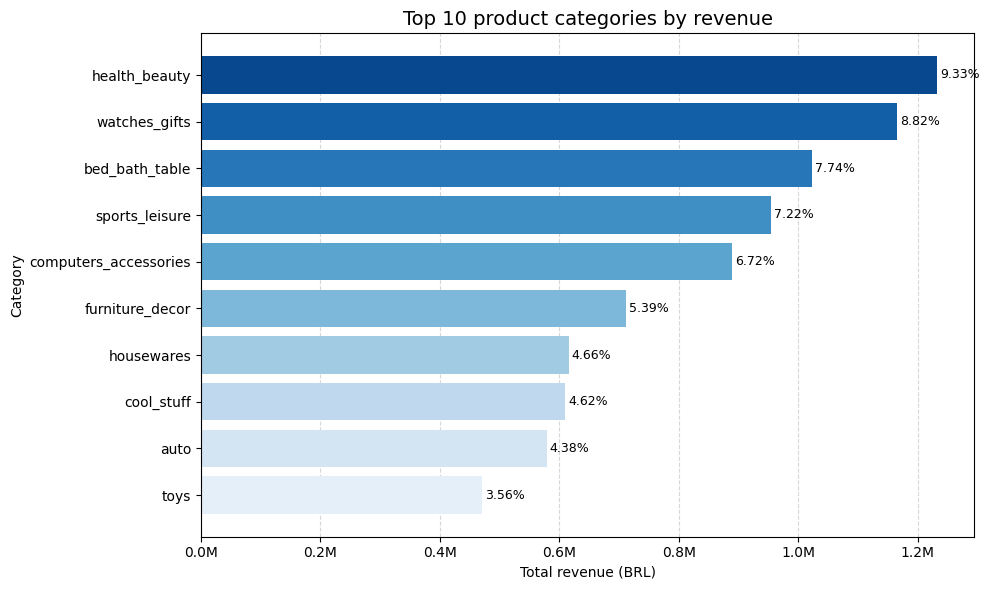

In [33]:
# Viz of top 10 product categories
fig, ax = plt.subplots(figsize=(10, 6))

top10 = category_revenue.head(10)

ax.barh(
    top10["product_category_name_english"],
    top10["total_revenue"],
    color=sns.color_palette("Blues_r", 10)
)

ax.set_title("Top 10 product categories by revenue", fontsize=14)
ax.set_xlabel("Total revenue (BRL)")
ax.set_ylabel("Category")
ax.xaxis.set_major_formatter(mtick.FuncFormatter(lambda x, _: f"{x/1e6:.1f}M"))


for i, (rev, pct) in enumerate(zip(top10["total_revenue"], top10["revenue_share_pct"])):
    ax.text(rev + 5000, i, f"{pct}%", va="center", fontsize=9)

ax.invert_yaxis()
ax.xaxis.grid(True, linestyle="--", alpha=0.5)
ax.yaxis.grid(False)
ax.set_axisbelow(True)
plt.tight_layout()
plt.savefig("viz_1_category_revenue.png", dpi=150)
plt.show()

The highest revenue-generating category was Health & Beauty, contributing approximately 9.3% of total sales revenue, followed by:
- Watches & Gifts — 8.8%
- Bed & Bath Table — 7.7%
- Sports & Leisure — 7.2%
- Computers & Accessories — 6.7%

The results suggest that customers show particularly strong demand for: personal care products, home-related items, electronics and accessories, lifestyle and leisure products.

**Key observations:**
- Revenue is spread across many categories — the top category holds less than 10% of total sales, indicating a well-diversified product portfolio
- `watches_gifts` has fewer orders than `bed_bath_table` (5,493 vs 9,272) but higher revenue, suggesting higher average order value
- Top 10 categories account for ~62% of total revenue

From a business perspective, these categories may represent the most valuable areas for:
- marketing investments,
- inventory prioritization,
- logistics optimization,
- seller partnerships.

### Question 2: How have revenue and order volume changed over time, and what seasonal patterns can be observed?

In [34]:
# Revenue and order volume over time
monthly_stats = (
    master_df.groupby("purchase_year_month")
    .agg(
        total_revenue=("price", "sum"),
        orders_count=("order_id", "nunique")
    )
    .reset_index()
    .sort_values("purchase_year_month")
)

monthly_stats.head(10)

,purchase_year_month,total_revenue,orders_count
0,2016-10,40325.11,265
1,2016-12,10.90,1
2,2017-01,111798.36,750
3,2017-02,234223.40,1653
4,2017-03,359198.85,2546
5,2017-04,340669.68,2303
6,2017-05,489159.25,3545
7,2017-06,421923.37,3135
8,2017-07,481604.52,3872
9,2017-08,554699.70,4193


A noticeable anomaly appears in December 2016, where the dataset contains only one recorded order. This likely reflects incomplete historical data rather than an actual business decline.

Before visualizing, two incomplete months were identified and excluded from the analysis:
- `2016-10` — first month in the dataset, only 265 orders (partial data)
- `2016-12` — only 1 order recorded (R$ 10.90), likely a data gap

The analysis covers the period from **January 2017 to August 2018**.

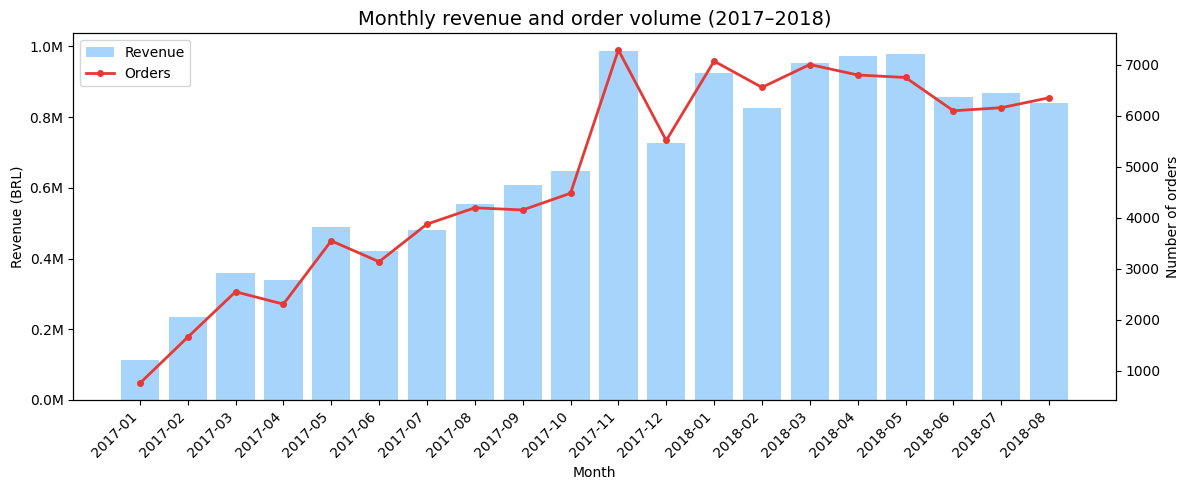

In [35]:
# Remove incomplete months
monthly_stats_clean = monthly_stats[
    ~monthly_stats["purchase_year_month"].isin(["2016-10", "2016-12"])
].reset_index(drop=True)

# Visualization dual axis: revenue + order volume
fig, ax1 = plt.subplots(figsize=(12, 5))

ax2 = ax1.twinx()

ax1.bar(
    monthly_stats_clean["purchase_year_month"],
    monthly_stats_clean["total_revenue"],
    color="#90CAF9",
    alpha=0.8,
    label="Revenue"
)

ax2.plot(
    monthly_stats_clean["purchase_year_month"],
    monthly_stats_clean["orders_count"],
    color="#E53935",
    linewidth=2,
    marker="o",
    markersize=4,
    label="Orders"
)

ax1.set_title("Monthly revenue and order volume (2017–2018)", fontsize=14)
ax1.set_xlabel("Month")
ax1.set_ylabel("Revenue (BRL)")
ax2.set_ylabel("Number of orders")
ax1.yaxis.set_major_formatter(mtick.FuncFormatter(lambda x, _: f"{x/1e6:.1f}M"))
ax1.set_xticks(range(len(monthly_stats_clean)))
ax1.set_xticklabels(monthly_stats_clean["purchase_year_month"], rotation=45, ha="right")

# Combined legend
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc="upper left")

plt.tight_layout()
plt.savefig("viz_2_monthly_revenue.png", dpi=150)
plt.show()

We can notice on the graph an overall growing trend and a strong positive relationship between monthly revenue and order volume, indicating that business growth was primarily driven by increasing customer activity. Both metrics move together throughout the period, suggesting the average order value remained stable over time.

From early 2017 through late 2017, both revenue and order counts grew steadily, demonstrating rapid expansion of the e-commerce platform.

Several important seasonal patterns can be observed:

- A significant peak occurred in November 2017, where both revenue and order volume reached their highest levels. This spike likely reflects the impact of Black Friday and holiday shopping campaigns.
- A noticeable decline followed in December 2017, which may indicate post-promotion normalization after the November sales peak.
- During 2018, revenue remained relatively stable at a high level, suggesting that the platform maintained strong customer demand.


### Question 3: How does delivery delay affect customer review scores — do late deliveries lead to lower ratings? 

In [36]:
# Delivery delay vs review score
delay_vs_review = (
    master_df[["delivery_delay_days", "review_score", "is_late"]]
    .dropna()
)

# Average review score: late vs on time
delay_summary = (
    delay_vs_review.groupby("is_late")["review_score"]
    .agg(["mean", "median", "count"])
    .round(2)
)
delay_summary.index = ["On time", "Late"]
delay_summary

,mean,median,count
On time,4.21,5.0,102279
Late,2.26,1.0,7080


The analysis reveals a strong relationship between delivery performance and customer satisfaction.

Orders delivered on time received an average review score of 4.21, while late deliveries received an average score of only 2.26.

The median review score further highlights this difference:
- on-time deliveries typically received the maximum rating of 5 stars,
- late deliveries most commonly received the minimum rating of 1 star.

These results indicate that delivery delays have a substantial negative impact on customer experience and overall satisfaction.

The findings suggest that logistics performance is one of the most critical operational factors affecting customer reviews and marketplace reputation.

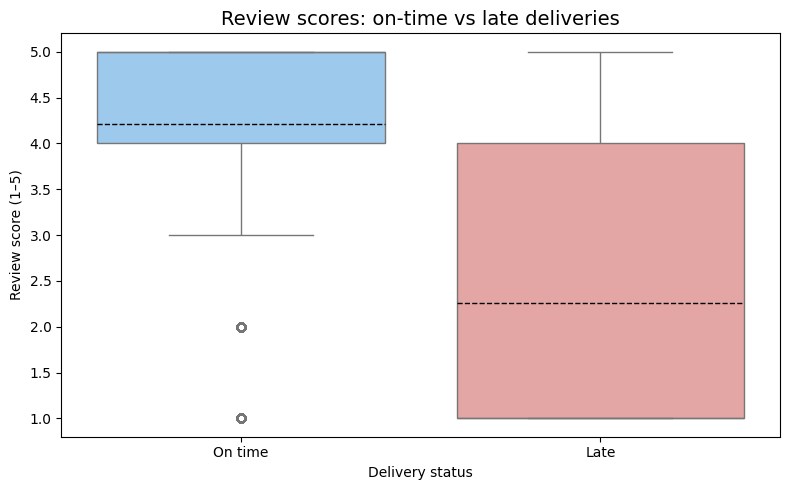

In [41]:
# Box-plot
fig, ax = plt.subplots(figsize=(8, 5))

sns.boxplot(
    data=delay_vs_review,
    x="is_late",
    y="review_score",
    hue="is_late",
    palette={False: "#90CAF9", True: "#EF9A9A"},
    legend=False,
    showmeans=True,
    meanprops={
        "linestyle": "--",
        "linewidth": 1,
        "color": "black"
    },
    meanline=True,
    ax=ax
)

ax.set_title("Review scores: on-time vs late deliveries", fontsize=14)
ax.set_xlabel("Delivery status")
ax.set_ylabel("Review score (1–5)")
ax.set_xticks([0, 1])
ax.set_xticklabels(["On time", "Late"])
ax.grid(False)

plt.tight_layout()
plt.savefig("viz_3_review_vs_delay.png", dpi=150)
plt.show()

The boxplot clearly demonstrates the impact of delivery delays on customer satisfaction.

Orders delivered on time show consistently high review scores, with most ratings concentrated between 4 and 5 stars and a median close to the maximum rating.

In contrast, late deliveries exhibit substantially lower review scores and much greater variability. The median score for delayed orders is close to 1 star, indicating a strong negative customer reaction to delivery issues.

The visualization confirms that delivery performance is a critical driver of customer satisfaction and overall marketplace experience.

### Question 4: Is there a statistically significant difference in review scores between orders delivered on time vs late deliveries? 

Hypothesis test — do late deliveries lead to lower review scores?

H₀: there is no significant difference in review scores between on-time and late deliveries.

H₁: late deliveries have significantly lower review scores.


In [42]:
# Preparing samples
on_time_scores = master_df[master_df["is_late"] == False]["review_score"].dropna()
late_scores    = master_df[master_df["is_late"] == True]["review_score"].dropna()

# Performing t-test
t_stat, p_value = stats.ttest_ind(on_time_scores, late_scores, equal_var=False)

print(f"On time — mean score: {on_time_scores.mean():.2f}, n = {len(on_time_scores):,}")
print(f"Late    — mean score: {late_scores.mean():.2f}, n = {len(late_scores):,}")
print(f"t-statistic: {t_stat:.3f}")
print(f"p-value:     {p_value:.10f}")

if p_value < 0.05:
    print("\nReject H0: late deliveries significantly lower review scores.")
else:
    print("\nFail to reject H0.")

On time — mean score: 4.21, n = 102,279
Late    — mean score: 2.26, n = 7,080
t-statistic: 102.272
p-value:     0.0000000000

Reject H0: late deliveries significantly lower review scores.


A two-sample t-test was used to compare review scores between on-time and late deliveries.

The average review score for on-time deliveries was 4.21, while late deliveries had an average score of 2.26.

The p-value was below 0.05, therefore the null hypothesis was rejected.

This provides strong statistical evidence that late deliveries are associated with significantly lower customer review scores.

### Question 5: Which states have the longest average delivery times, and how does this correlate with customer satisfaction?

In [43]:
# Average delivery time and review score by state
state_stats = (
    master_df.groupby("customer_state")
    .agg(
        avg_delivery_days=("delivery_delay_days", "mean"),
        avg_review_score=("review_score", "mean"),
        orders_count=("order_id", "nunique")
    )
    .round(2)
    .reset_index()
    .sort_values("avg_delivery_days", ascending=False)
)

state_stats.head(10)

,customer_state,avg_delivery_days,avg_review_score,orders_count
21,RR,27.83,3.89,41
3,AP,27.75,4.26,67
2,AM,25.96,4.11,145
1,AL,23.99,3.83,397
13,PA,23.30,3.84,946
9,MA,21.20,3.76,717
24,SE,20.98,3.90,335
5,CE,20.54,3.88,1279
0,AC,20.33,4.13,80
14,PB,20.12,4.04,517


Pearson correlation: -0.312


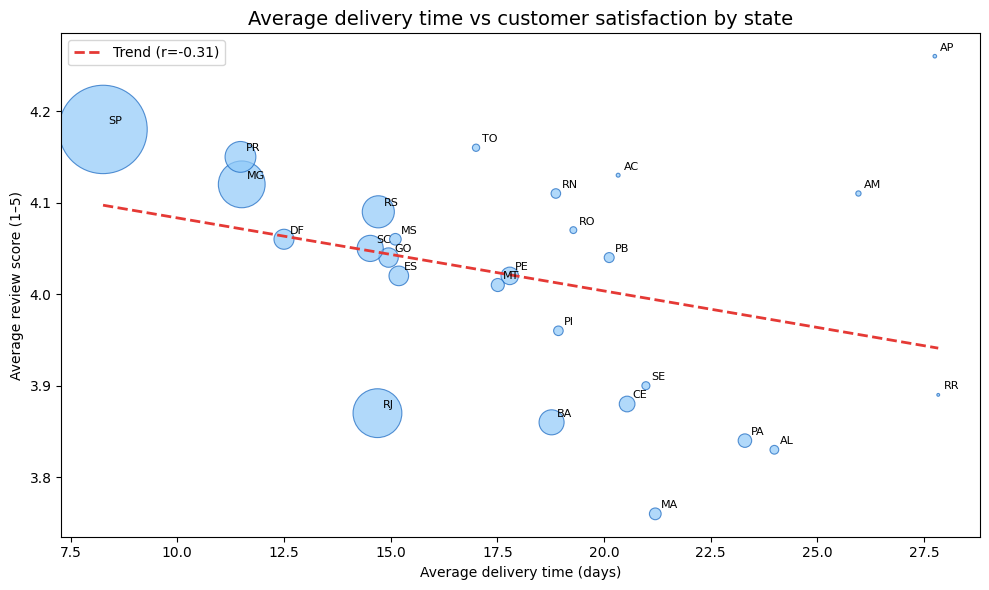

In [44]:
# Correlation between delivery time and review score
correlation = state_stats["avg_delivery_days"].corr(state_stats["avg_review_score"])
print(f"Pearson correlation: {correlation:.3f}")

# Scatter plot: delivery days vs review score
fig, ax = plt.subplots(figsize=(10, 6))

scatter = ax.scatter(
    state_stats["avg_delivery_days"],
    state_stats["avg_review_score"],
    s=state_stats["orders_count"] / 10,
    alpha=0.7,
    color="#90CAF9",
    edgecolors="#1565C0",
    linewidth=0.8
)

# State labels
for _, row in state_stats.iterrows():
    ax.annotate(
        row["customer_state"],
        (row["avg_delivery_days"], row["avg_review_score"]),
        fontsize=8,
        ha="left",
        xytext=(4, 4),
        textcoords="offset points"
    )

# Trend line
m, b = np.polyfit(state_stats["avg_delivery_days"], state_stats["avg_review_score"], 1)
x_range = np.linspace(state_stats["avg_delivery_days"].min(), 
                       state_stats["avg_delivery_days"].max(), 100)
ax.plot(x_range, m * x_range + b, color="#E53935", linewidth=2, 
        linestyle="--", label=f"Trend (r={correlation:.2f})")

ax.set_title("Average delivery time vs customer satisfaction by state", fontsize=14)
ax.set_xlabel("Average delivery time (days)")
ax.set_ylabel("Average review score (1–5)")
ax.legend()
ax.grid(False)

plt.tight_layout()
plt.savefig("viz_4_state_delivery_satisfaction.png", dpi=150)
plt.show()

We can see a moderate negative correlation between average delivery time and customer satisfaction across Brazilian states (Pearson correlation = -0.31).

In general, states with longer delivery times tended to receive lower average review scores, suggesting that slower logistics negatively affect customer experience. 

However r = -0.31 is not that strong and means that delivery time is *one of several* factors affecting satisfaction.

São Paulo (SP), which generated the highest order volume, demonstrated one of the shortest delivery times and maintained high customer satisfaction. This may reflect stronger logistics infrastructure and higher operational efficiency in the region.

Several northern and geographically remote states, including RR, AP, and AM, experienced the longest average delivery times. However, customer satisfaction patterns varied between these regions, suggesting that delivery expectations and customer behavior may differ across states.

States such as Maranhão (MA), Alagoas (AL), and Pará (PA) combined relatively long delivery times with lower review scores, indicating potential areas for logistics improvement.

Overall, the results reinforce the importance of delivery performance as a key driver of customer satisfaction and operational success.

### Question 6: Which states contribute the most to revenue and customer activity?

A pivot table was created to summarize key metrics by customer state: total revenue, number of orders, unique customers, and revenue share.

In [45]:
# Pivot table — state performance summary
pivot_table = master_df.merge(
    customers[["customer_id", "customer_unique_id"]], on="customer_id"
).pivot_table(
    index="customer_state",
    values=["price", "order_id", "customer_unique_id"],
    aggfunc={
        "price": "sum",
        "order_id": "nunique",
        "customer_unique_id": "nunique"
    }
).round(2)

pivot_table.columns = ["unique_customers", "orders_count", "total_revenue"]
pivot_table["revenue_share_pct"] = (
    pivot_table["total_revenue"] / pivot_table["total_revenue"].sum() * 100
).round(2)

pivot_table = pivot_table.sort_values("total_revenue", ascending=False)
pivot_table.head(10)

,unique_customers,orders_count,total_revenue,revenue_share_pct
customer_state,,,,
SP,39148,40493,5066428.01,38.32
RJ,11917,12350,1759651.13,13.31
MG,11001,11354,1552481.83,11.74
RS,5167,5344,728718.47,5.51
PR,4769,4923,666063.51,5.04
SC,3449,3546,507012.13,3.84
BA,3158,3256,493584.14,3.73
DF,2019,2080,296498.41,2.24
GO,1895,1957,282836.70,2.14


The analysis reveals a strong geographic concentration of both customer activity and revenue within a small number of Brazilian states.

São Paulo (SP)  dominates with 5.07M — 38.32% of total revenue and 39,148 unique customers

This means that more than one-third of all marketplace revenue originated from a single state, highlighting São Paulo as the platform’s primary commercial hub.

Rio de Janeiro (RJ) and Minas Gerais (MG) ranked second and third in both customer activity and revenue generation, together contributing an additional 25% of total revenue. These are the most populous and economically developed states in Brazil.

Southern and southeastern states such as RS, PR, and SC also demonstrated relatively strong commercial performance, while other regions contributed significantly smaller revenue shares.

In most states `orders_count` slightly exceeds `unique_customers`, confirming some repeat purchasing behavior. `SP` has the largest gap: 40,493 orders vs 39,148 customers.

Remaining 17 states share only ~14% of total revenue making a significant geographic concentration risk for the business.

These findings suggest that:
- marketplace activity is heavily concentrated in economically developed regions,
- logistics infrastructure and population density likely play an important role in sales performance,
- and geographic expansion opportunities exist in underrepresented states.

From a business perspective, the results support prioritizing:
- customer retention strategies in high-performing states,
- logistics optimization in major regions,
- and targeted marketing efforts in emerging markets with lower penetration.

### Question 7: What is the repeat purchase rate — how many customers made more than one order?

In [46]:
# Repeat purchase rate
print(f"Total unique customers:   {len(repeat_customers):,}")
print(f"Repeat customers:         {repeat_customers['is_repeat_customer'].sum():,}")
print(f"Repeat purchase rate:     {repeat_customers['is_repeat_customer'].mean()*100:.2f}%")

# Distribution of order counts
repeat_customers["order_count"].value_counts().sort_index().head(10)

Total unique customers:   93,350
Repeat customers:         2,801
Repeat purchase rate:     3.00%


order_count
1     90549
2      2573
3       181
4        28
5         9
6         5
7         3
9         1
15        1
Name: count, dtype: int64

Note: Analysis is based on 93,350 customers with at least one delivered order, excluding customers whose orders were cancelled or not yet delivered.

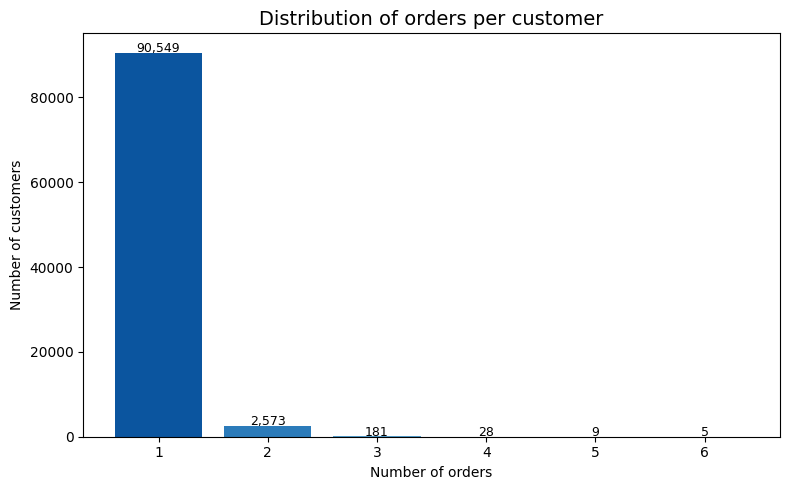

In [47]:
# Order count distribution
fig, ax = plt.subplots(figsize=(8, 5))

order_dist = repeat_customers["order_count"].value_counts().sort_index().head(6)

ax.bar(
    order_dist.index.astype(str),
    order_dist.values,
    color=sns.color_palette("Blues_r", 6)
)

ax.set_title("Distribution of orders per customer", fontsize=14)
ax.set_xlabel("Number of orders")
ax.set_ylabel("Number of customers")
ax.grid(False)

# Value labels on bars
for i, v in enumerate(order_dist.values):
    ax.text(i, v + 100, f"{v:,}", ha="center", fontsize=9)

plt.tight_layout()
plt.savefig("viz_5_repeat_customers.png", dpi=150)
plt.show()

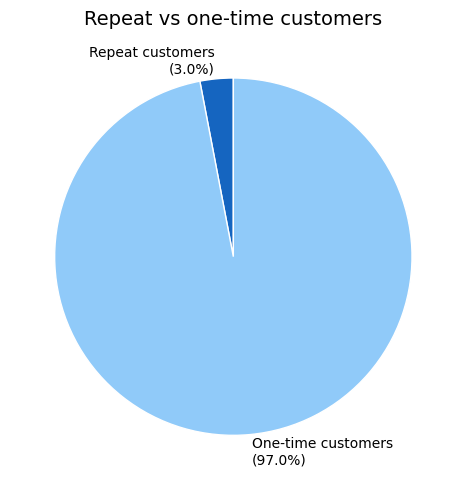

In [48]:
# Pie-chart of one-time vs repeat customers ratio
fig, ax = plt.subplots(figsize=(8,5))

sizes = [
    repeat_customers["is_repeat_customer"].sum(),
    (~repeat_customers["is_repeat_customer"]).sum()
]
labels = [
    f"Repeat customers\n({repeat_customers['is_repeat_customer'].mean()*100:.1f}%)",
    f"One-time customers\n({(~repeat_customers['is_repeat_customer']).mean()*100:.1f}%)"
]

ax.pie(
    sizes,
    labels=labels,
    colors=["#1565C0", "#90CAF9"],
    startangle=90,
    wedgeprops={"edgecolor": "white", "linewidth": 1}
)

ax.set_title("Repeat vs one-time customers", fontsize=14)

plt.tight_layout()
plt.savefig("viz_6_repeat_customers.png", dpi=150)
plt.show()

Out of more than 93,000 unique customers, only approximately 3% returned to place additional orders. Most repeat customers made only two purchases, while customers with three or more orders were extremely rare.

These results suggest that the marketplace experienced extremely low retention rate during the observed period.

From a business perspective, improving repeat purchase behavior could represent a major opportunity for long-term revenue growth and customer lifetime value expansion. Loyalty programs or personalized recommendations could significantly improve this metric

### Question 8: Which sellers generate the highest revenue and customer satisfaction scores?

In [49]:
# Top sellers by revenue and satisfaction
seller_stats = (
    master_df.groupby(["seller_id", "seller_state"])
    .agg(
        total_revenue=("price", "sum"),
        orders_count=("order_id", "nunique"),
        avg_review_score=("review_score", "mean")
    )
    .round(2)
    .reset_index()
    .sort_values("total_revenue", ascending=False)
)

seller_stats.head(10)

,seller_id,seller_state,total_revenue,orders_count,avg_review_score
834,4869f7a5dfa277a7dca6462dcf3b52b2,SP,226987.93,1124,4.14
982,53243585a1d6dc2643021fd1853d8905,BA,217940.44,348,4.13
858,4a3ca9315b744ce9f8e9374361493884,SP,196882.12,1772,3.83
2903,fa1c13f2614d7b5c4749cbc52fecda94,SP,190917.14,578,4.37
1480,7c67e1448b00f6e969d365cea6b010ab,SP,186570.05,973,3.35
1504,7e93a43ef30c4f03f38b393420bc753a,SP,165981.49,319,4.36
2543,da8622b14eb17ae2831f4ac5b9dab84a,SP,159816.87,1311,4.07
1450,7a67c85e85bb2ce8582c35f2203ad736,SP,139658.69,1145,4.27
188,1025f0e2d44d7041d6cf58b6550e0bfa,SP,138208.56,910,3.88
1758,955fee9216a65b617aa5c0531780ce60,SP,131836.71,1261,4.09


The highest-performing seller generated more than 226 thousand BRL in revenue and completed over 1,100 orders while maintaining a strong average review score above 4.1. This indicates a combination of high operational scale and positive customer experience.

Several other sellers also demonstrated strong performance, combining high sales volume, large order counts, and consistently positive customer ratings.

The analysis also identified sellers with high revenue but noticeably lower review scores. For example:
- one large seller processed nearly 1,000 orders but maintained an average review score close to 3.35,
- another high-volume seller with more than 1,700 orders had an average review score below 4.

From a business perspective, the platform may benefit from:
- monitoring low-rated high-volume sellers,
- identifying best practices among top-performing merchants,
- and improving operational support for rapidly growing sellers.

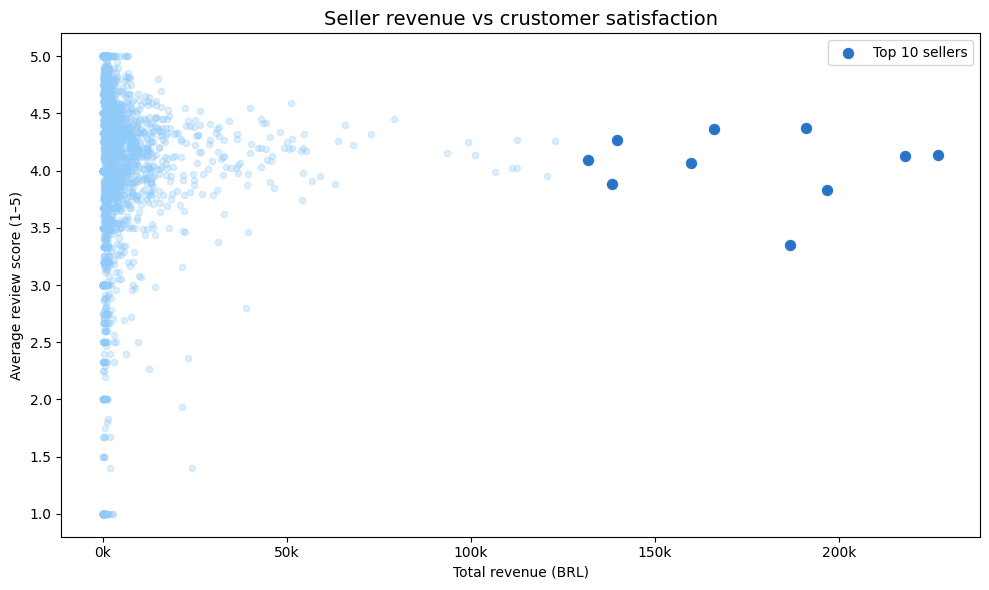

In [50]:
# Scatter plot: revenue vs review score
fig, ax = plt.subplots(figsize=(10, 6))

# All sellers as background
ax.scatter(
    seller_stats["total_revenue"],
    seller_stats["avg_review_score"],
    alpha=0.3,
    s=20,
    color="#90CAF9"
)

# Top 10 highlighted
top10_sellers = seller_stats.head(10)
ax.scatter(
    top10_sellers["total_revenue"],
    top10_sellers["avg_review_score"],
    alpha=0.9,
    s=80,
    color="#1565C0",
    edgecolors="white",
    linewidth=0.8,
    label="Top 10 sellers"
)

ax.set_title("Seller revenue vs crustomer satisfaction", fontsize=14)
ax.set_xlabel("Total revenue (BRL)")
ax.set_ylabel("Average review score (1–5)")
ax.xaxis.set_major_formatter(mtick.FuncFormatter(lambda x, _: f"{x/1e3:.0f}k"))
ax.legend()
ax.grid(False)

plt.tight_layout()
plt.savefig("viz_7_seller_stats.png", dpi=150)
plt.show()

The scatterplot highlights that most sellers are concentrated in the lower revenue range, while only a small number of sellers generate exceptionally high revenue. This suggests that marketplace sales are heavily concentrated among a limited group of top-performing merchants.

The visualization also shows that high revenue does not automatically guarantee high customer satisfaction:
- some top sellers maintain strong review scores above 4.2,
- while others receive noticeably lower ratings despite large sales volumes.


At the same time, several high-revenue sellers successfully maintain strong customer satisfaction, demonstrating that it is possible to combine operational scale with positive customer experience.

Overall, the analysis suggests that the marketplace should monitor both revenue AND satisfaction to identify high-volume sellers with poor customer experience.

### Question 9: Which payment methods are most popular, and do they differ by order value?

In [51]:
# Payment methods analysis
payment_stats = (
    payments.groupby("payment_type")
    .agg(
        transactions=("order_id", "count"),
        avg_order_value=("payment_value", "mean"),
        total_value=("payment_value", "sum")
    )
    .round(2)
    .reset_index()
    .sort_values("transactions", ascending=False)
)

payment_stats["transactions_pct"] = (
    payment_stats["transactions"] / payment_stats["transactions"].sum() * 100
).round(2)

payment_stats

,payment_type,transactions,avg_order_value,total_value,transactions_pct
1,credit_card,76795,163.32,12542084.19,73.92
0,boleto,19784,145.03,2869361.27,19.04
4,voucher,5775,65.70,379436.87,5.56
2,debit_card,1529,142.57,217989.79,1.47
3,not_defined,3,0.00,0.00,0.00


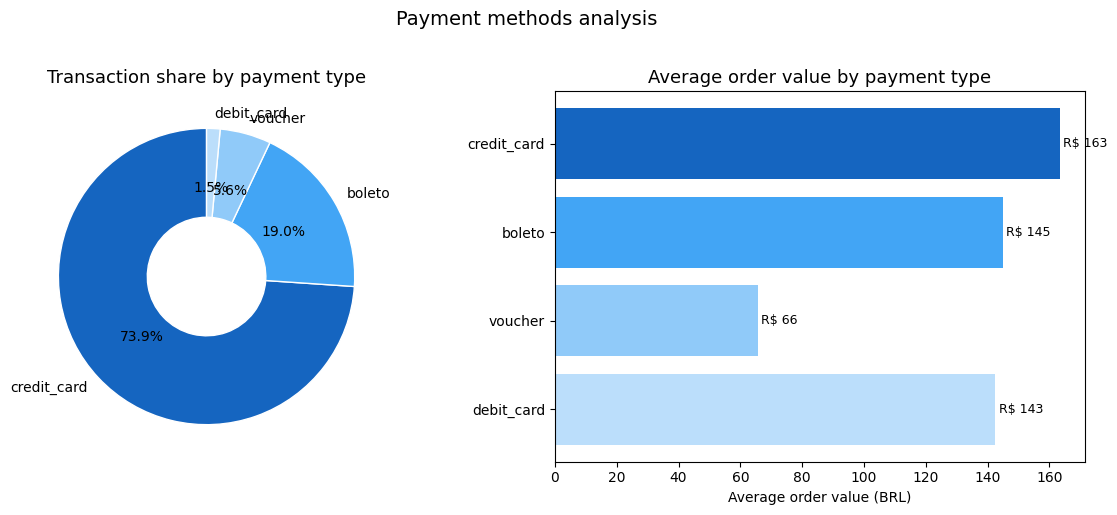

In [52]:
# Removing not_defined 3 transactions with zero value
payment_clean = payment_stats[payment_stats["payment_type"] != "not_defined"]

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Donut chart: transaction share
sizes = payment_clean["transactions_pct"]
labels = payment_clean["payment_type"]
colors = ["#1565C0", "#42A5F5", "#90CAF9", "#BBDEFB"]

wedges, texts, autotexts = axes[0].pie(
    sizes,
    labels=labels,
    colors=colors,
    autopct="%1.1f%%",
    startangle=90,
    wedgeprops={"edgecolor": "white", "linewidth": 1, "width": 0.6}
)
axes[0].set_title("Transaction share by payment type", fontsize=13)

# Horizontal bar: avg order value
axes[1].barh(
    payment_clean["payment_type"],
    payment_clean["avg_order_value"],
    color=colors
)
axes[1].set_title("Average order value by payment type", fontsize=13)
axes[1].set_xlabel("Average order value (BRL)")
axes[1].invert_yaxis()
axes[1].grid(False)

for i, v in enumerate(payment_clean["avg_order_value"]):
    axes[1].text(v + 1, i, f"R$ {v:.0f}", va="center", fontsize=9)

plt.suptitle("Payment methods analysis", fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig("viz_8_payment_methods.png", dpi=150)
plt.show()

Credit cards are the dominant payment method on the platform, accounting for nearly 74% of all transactions.

Boleto was the second most popular payment method, representing approximately 19% of purchases, while voucher and debit card payments accounted for relatively small shares of total transactions.

Payment methods also demonstrated noticeable differences in average order value:
- credit card purchases had the highest average order value,
- boleto and debit card payments showed slightly lower but still relatively high average purchase amounts,
- voucher payments had substantially lower average order values, averaging only around R$66.

These results suggest that customers using credit cards tend to place larger and potentially more valuable orders, possibly due to: installment payment flexibility, greater purchasing convenience, or higher customer purchasing power.

The dominance of credit card transactions indicates that payment flexibility likely plays an important role in customer purchasing behavior.

From a business perspective, the marketplace may benefit from:
- optimizing the credit card checkout experience,
- promoting installment payment options.

### Question 10: Which product categories receive the lowest review scores, and what factors may contribute to customer dissatisfaction?

In [53]:
# Categories with lowest review scores
category_reviews = (
    master_df.groupby("product_category_name_english")
    .agg(
        avg_review_score=("review_score", "mean"),
        total_reviews=("review_score", "count"),
        avg_delivery_days=("delivery_delay_days", "mean"),
        late_rate=("is_late", "mean")
    )
    .round(2)
    .reset_index()
)

# Min 100 reviews for statistical reliability
category_reviews = category_reviews[category_reviews["total_reviews"] >= 100]

category_reviews_sorted = category_reviews.sort_values("avg_review_score")
category_reviews_sorted.head(10)

,product_category_name_english,avg_review_score,total_reviews,avg_delivery_days,late_rate
57,office_furniture,3.52,1654,20.39,0.08
34,fixed_telephony,3.76,252,12.24,0.04
30,fashion_male_clothing,3.76,124,12.47,0.06
4,audio,3.84,358,12.88,0.12
47,home_confort,3.86,427,13.04,0.09
7,bed_bath_table,3.92,10831,12.34,0.07
40,furniture_living_room,3.93,490,13.29,0.07
70,unknown,3.93,1547,12.26,0.07
48,home_construction,3.96,592,12.76,0.06
39,furniture_decor,3.96,8080,12.40,0.07


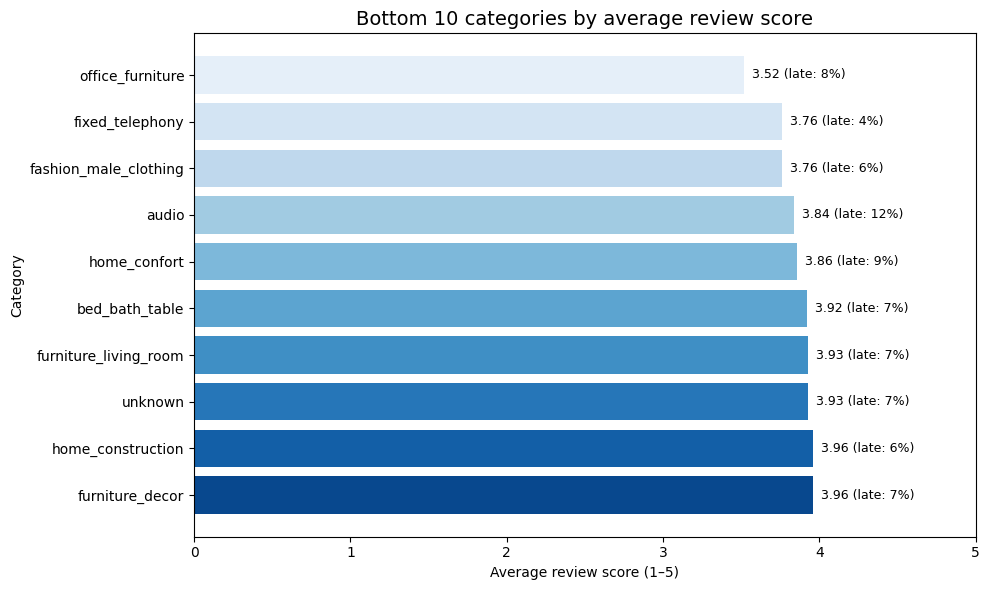

In [54]:
# Bottom 10 categories by review score
bottom10 = category_reviews_sorted.head(10)

fig, ax = plt.subplots(figsize=(10, 6))

bars = ax.barh(
    bottom10["product_category_name_english"],
    bottom10["avg_review_score"],
    color=sns.color_palette("Blues", 10)
)

ax.set_title("Bottom 10 categories by average review score", fontsize=14)
ax.set_xlabel("Average review score (1–5)")
ax.set_ylabel("Category")
ax.set_xlim(0, 5)
ax.invert_yaxis()
ax.grid(False)

# Add score labels
for i, (score, late) in enumerate(zip(bottom10["avg_review_score"],
                                       bottom10["late_rate"])):
    ax.text(score + 0.05, i, f"{score} (late: {late*100:.0f}%)",
            va="center", fontsize=9)

plt.tight_layout()
plt.savefig("viz_9_category_reviews.png", dpi=150)
plt.show()

The category with the lowest average review score is Office Furniture, with an average rating of only 3.52. This category also had one of the longest average delivery times (over 20 days), suggesting that logistics challenges may strongly contribute to customer dissatisfaction.

Other low-rated categories included:
- Fixed Telephony,
- Fashion Male Clothing,
- Audio,
- Home Comfort,
- Furniture & Decor-related products.

For furniture categories (office, living room, decor) — long delivery times correlate with low scores. This might be explained by the fact that many products are large or fragile, making shipping and delivery more difficult.
For electronics and clothing — dissatisfaction likely stems from  product quality or unmet expectations, not delivery

The following options can be recommended for business:
- improving packaging,
- optimizing shipping processes,
- improving seller quality control,
- enhancing delivery communication with customers.

## Conclusions and Business Recommendations

### Key Insights

**Sales & Revenue**
- The platform showed strong growth throughout 2017, with revenue peaking in November 2017 driven by Black Friday. By 2018 the business reached a stable mature phase (~R$ 800k–980k/month)
- `health_beauty`, `watches_gifts` and `bed_bath_table` are the top 3 revenue-generating categories, collectively accounting for ~26% of total revenue
- Revenue is heavily concentrated geographically — São Paulo alone generates 38% of total revenue, and top 3 states (SP, RJ, MG) account for 63%

**Delivery & Operations**
- Average delivery time varies significantly by state — northern states (RR, AP, AM) wait 26–28 days vs ~8 days in São Paulo
- 7% of delivered orders are late (delivered after estimated date)
- Late deliveries are strongly associated with lower review scores (2.26 vs 4.21 on time), confirmed by statistically significant t-test (p < 0.05)

**Customer Behavior**
- Repeat purchase rate is extremely low at **3%** — 97% of customers buy only once
- Credit card is a dominating payment methods (74% of transactions) with highest average order value (R$ 163)
- Vouchers are used for low-value purchases (avg R$ 66)

**Product Quality**
- `office_furniture` has the lowest review score (3.52) combined with longest delivery time (20 days)
- `audio` category has the highest late delivery rate (12%) among low-rated categories


### Business Recommendations

1. **Improve delivery in northern states** — partner with local logistics providers in RR, AP, AM to reduce delivery times and improve customer satisfaction.

2. **Focus retention efforts** — with only 3% repeat purchase rate, implementing a loyalty program or personalized email campaigns could significantly increase customer lifetime value.

3. **Monitor low-satisfaction sellers** — sellers with high revenue but low scores (e.g. score 3.35) pose a reputational risk and should be flagged for quality review.

4. **Investigate office furniture category** — longest delivery time and lowest satisfaction score suggest systemic issues with suppliers or logistics for large/heavy items.

5. **Expand beyond São Paulo** — heavy geographic concentration is a business risk; targeted marketing in underrepresented states could diversify revenue streams.

6. **Leverage Black Friday** — the November 2017 spike confirms strong seasonal demand; preparing inventory and logistics in advance could maximize this opportunity.

## Tableau Dashboard

Interactive dashboard published on Tableau Public:
[Brazilian E-Commerce Analysis](https://public.tableau.com/views/BrazilianE-CommerceAnalysis_17790304439800/SalesOverview?:language=en-US&publish=yes&:sid=&:redirect=auth&:display_count=n&:origin=viz_share_link)

**Dashboard 1 — Sales Overview:** revenue trend, geographic distribution, top categories  
**Dashboard 2 — Quality & Payments:** delivery performance, lowest rated categories, payment methods